In [1]:
import re
from collections import defaultdict
import statistics
import matplotlib.pyplot as plt
import csv
import numpy as np
def load_voltage(file,plot = False): # return array
    # load voltage as 512*512*4 array
    array = []
    with open(file) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        for row in csv_reader:
            for value in row[2:]:
                array.append((float(value)))
    array = np.array(array).reshape((512,512,4))
    # only retain values with circle with r = 256
    mask = np.zeros((512,512), dtype=bool)
    for i in range(512):
        for j in range(512):
            r2 = (i - 256) ** 2 + (j - 256) ** 2
            if r2 <= (256) ** 2:
                mask[i, j] = True
    array[~mask] = np.nan
    if plot:
        plt.imshow(array[:,:,0])
    return array

csv_path = r"./results_summary.csv"

pattern = re.compile(r"tip_omega_(\d+)_Emax_(\d+)_IC(\d+)_mask(\d+)_(\d+)ms")

# recursive defaultdict factory
def nested_dict():
    return defaultdict(nested_dict)

data = nested_dict()

with open(csv_path, "r", encoding="utf-8") as f:
    next(f)  # skip header line
    for line in f:
        line = line.strip()
        if not line:
            continue

        filepath, num1_str, num2_str = line.split(",")
        match = pattern.search(filepath)
        if match:
            omega, Emax, IC, mask, time = map(int, match.groups())
            num1 = int(num1_str)
            num2 = float(num2_str)

            data[omega][Emax][IC][mask][time]["SN"] = num1
            data[omega][Emax][IC][mask][time]["FTE"] = num2

# Example access
# print(data[0][160][8][1][498]["FTE"])

In [4]:
omega = [0,50,100]
Emax = [100, 200, 300, 350]
IC = list(range(1, 8))  # 1 to 8
mask = list(range(1, 6))  # 1 to 5
time = [350]
result = []
result_std = []
for n1 in omega:
    for n2 in Emax:
        curSN = []
        curFTE = []
        for n3 in IC:
            for n4 in mask:
                for t in time:
                    SN = data[n1][n2][n3][n4][t]["SN"]
                    if type(SN) is not int:
                        print(f"SN not int for omega={n1}, Emax={n2}, IC={n3}, mask={n4}, time={t}ms")
                    FTE = data[n1][n2][n3][n4][t]["FTE"]
                    if type(FTE) is not float:
                        print(f"FTE not float for omega={n1}, Emax={n2}, IC={n3}, mask={n4}, time={t}ms")
                    if t == 350:
                        curSN.append(SN)
                        curFTE.append(FTE)
        result.append((sum(curSN)/len(curSN), sum(curFTE)/len(curFTE)))
        result_std.append((statistics.stdev(curSN), statistics.stdev(curFTE)))

In [7]:
result

[(4.228571428571429, 0.4157411847795759),
 (2.6285714285714286, 0.35527943202427453),
 (2.6285714285714286, 0.36760210309709823),
 (2.057142857142857, 0.32573580060686386),
 (3.8857142857142857, 0.4517907278878348),
 (2.742857142857143, 0.372711181640625),
 (1.7142857142857142, 0.36732395717075894),
 (2.5142857142857142, 0.3924192156110491),
 (3.8857142857142857, 0.4515070234026228),
 (2.8285714285714287, 0.3551981244768415),
 (2.5428571428571427, 0.36556069510323663),
 (2.4, 0.34570672171456474)]

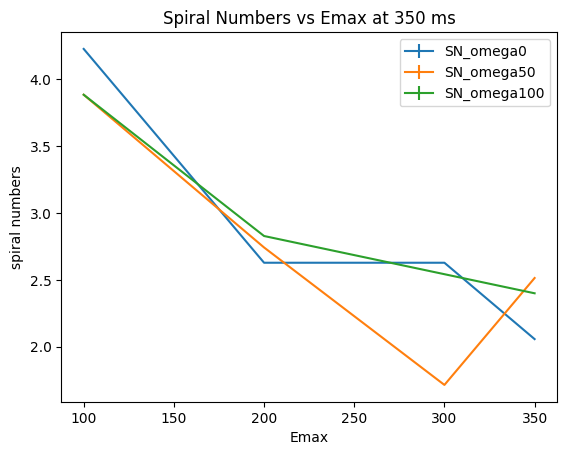

In [12]:
plt.errorbar(Emax,[i[0] for i in result[:4]],yerr=[0 for i in result_std[:4]], label="SN_omega0")
plt.errorbar(Emax,[i[0] for i in result[4:8]], yerr=[0 for i in result_std[4:8]], label="SN_omega50")
plt.errorbar(Emax,[i[0] for i in result[8:12]], yerr=[0 for i in result_std[8:12]], label="SN_omega100")
plt.legend()
plt.xlabel("Emax")
plt.ylabel("spiral numbers")
plt.title(f"Spiral Numbers vs Emax at {time[0]} ms")
plt.savefig(f"SN_vs_Emax_{time[0]}ms.png")
plt.show()

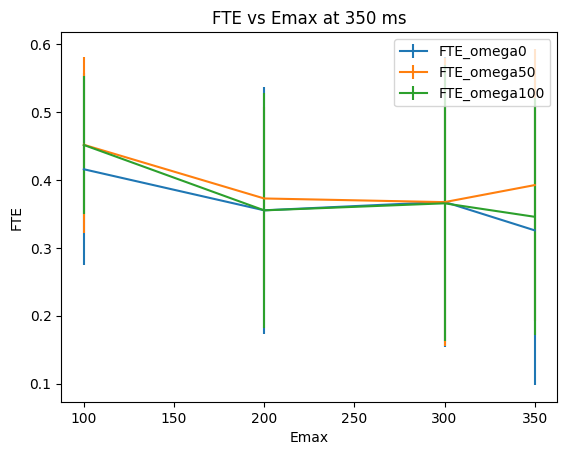

In [6]:
plt.errorbar(Emax,[i[1] for i in result[:4]], yerr=[i[1] for i in result_std[:4]], label="FTE_omega0")
plt.errorbar(Emax,[i[1] for i in result[4:8]], yerr=[i[1] for i in result_std[4:8]], label="FTE_omega50")
plt.errorbar(Emax,[i[1] for i in result[8:12]], yerr=[i[1] for i in result_std[8:12]], label="FTE_omega100")
plt.legend()
plt.xlabel("Emax")
plt.ylabel("FTE")
plt.title(f"FTE vs Emax at {time[0]} ms")
plt.savefig(f"FTE_vs_Emax_{time[0]}ms.png")
plt.show()